In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_auc_score, precision_recall_curve, auc
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_effectsize
from statsmodels.stats.power import NormalIndPower
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

np.random.seed(42)

### Loading Data and Champion Model

In [32]:
X_test = pd.read_csv('data/processed/X_test.csv')
y_test = pd.read_csv('data/processed/y_test.csv').values.ravel()

with open('models/champion_meta.json') as f:
    meta = json.load(f)

optimal_threshold = meta['optimal_threshold']   # business-cost optimal from notebook 03

# Champion model: LightGBM Tuned
lgbm_model = joblib.load('models/xgb_tuned.pkl')
prob = lgbm_model.predict_proba(X_test)[:, 1]   # probability scores -- same for both arms

# Cost parameters
avg_fraud_amt = 120.0   # $ lost per missed fraud (false negative)
false_positive_cost =   5.0   # $ friction per wrongly blocked transaction

print(f'Test set: {len(y_test):,} transactions | Fraud rate: {y_test.mean()*100:.2f}%')
print(f'Fraud cases: {y_test.sum():,} | Legitimate: {(y_test==0).sum():,}')
print(f'Control threshold  : 0.50 (naive default)')
print(f'Treatment threshold: {optimal_threshold:.2f} (business-cost optimal from notebook 03)')

Test set: 88,581 transactions | Fraud rate: 3.48%
Fraud cases: 3,083 | Legitimate: 85,498
Control threshold  : 0.50 (naive default)
Treatment threshold: 0.40 (business-cost optimal from notebook 03)


### Primary Metrics

In [33]:
def compute_metrics(y_true, y_pred, y_prob, label=''):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    n = len(y_true)
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    fn_cost = fn * avg_fraud_amt
    fp_cost = fp * false_positive_cost
    total_cost = fn_cost + fp_cost
    return dict(
        label=label, tp=tp, fp=fp, fn=fn, tn=tn,
        precision=prec, recall=rec, f1=f1, fpr=fpr,
        fn_cost=fn_cost, fp_cost=fp_cost, total_cost=total_cost
    )

# Computing for both arms
thresh_control = 0.50
thresh_treatment = optimal_threshold

pred_ctrl = (prob >= thresh_control).astype(int)
pred_trt  = (prob >= thresh_treatment).astype(int)

m_ctrl = compute_metrics(y_test, pred_ctrl, prob, 'Control (t=0.50)')
m_trt  = compute_metrics(y_test, pred_trt,  prob, f'Treatment (t={thresh_treatment:.2f})')

print(f'Metrics at Control threshold (0.50):')
print(f'Recall: {m_ctrl["recall"]:.4f}  Precision: {m_ctrl["precision"]:.4f}  '
      f'F1: {m_ctrl["f1"]:.4f}  FPR: {m_ctrl["fpr"]:.4f}')
print(f'Business cost: ${m_ctrl["total_cost"]:,.0f}')
print()
print(f'Metrics at Treatment threshold ({thresh_treatment:.2f}):')
print(f'Recall: {m_trt["recall"]:.4f}  Precision: {m_trt["precision"]:.4f}  '
      f'F1: {m_trt["f1"]:.4f}  FPR: {m_trt["fpr"]:.4f}')
print(f'Business cost: ${m_trt["total_cost"]:,.0f}')

Metrics at Control threshold (0.50):
Recall: 0.5031  Precision: 0.7224  F1: 0.5931  FPR: 0.0070
Business cost: $186,820

Metrics at Treatment threshold (0.40):
Recall: 0.5319  Precision: 0.6755  F1: 0.5952  FPR: 0.0092
Business cost: $177,100


### Threshold Sweep

Evaluating precision, recall, F1, FPR, and business cost across the full threshold range 0.1 to 0.9. This gives the full operating characteristic of the model and shows where the control (0.5) and treatment thresholds sit relative to all alternatives.

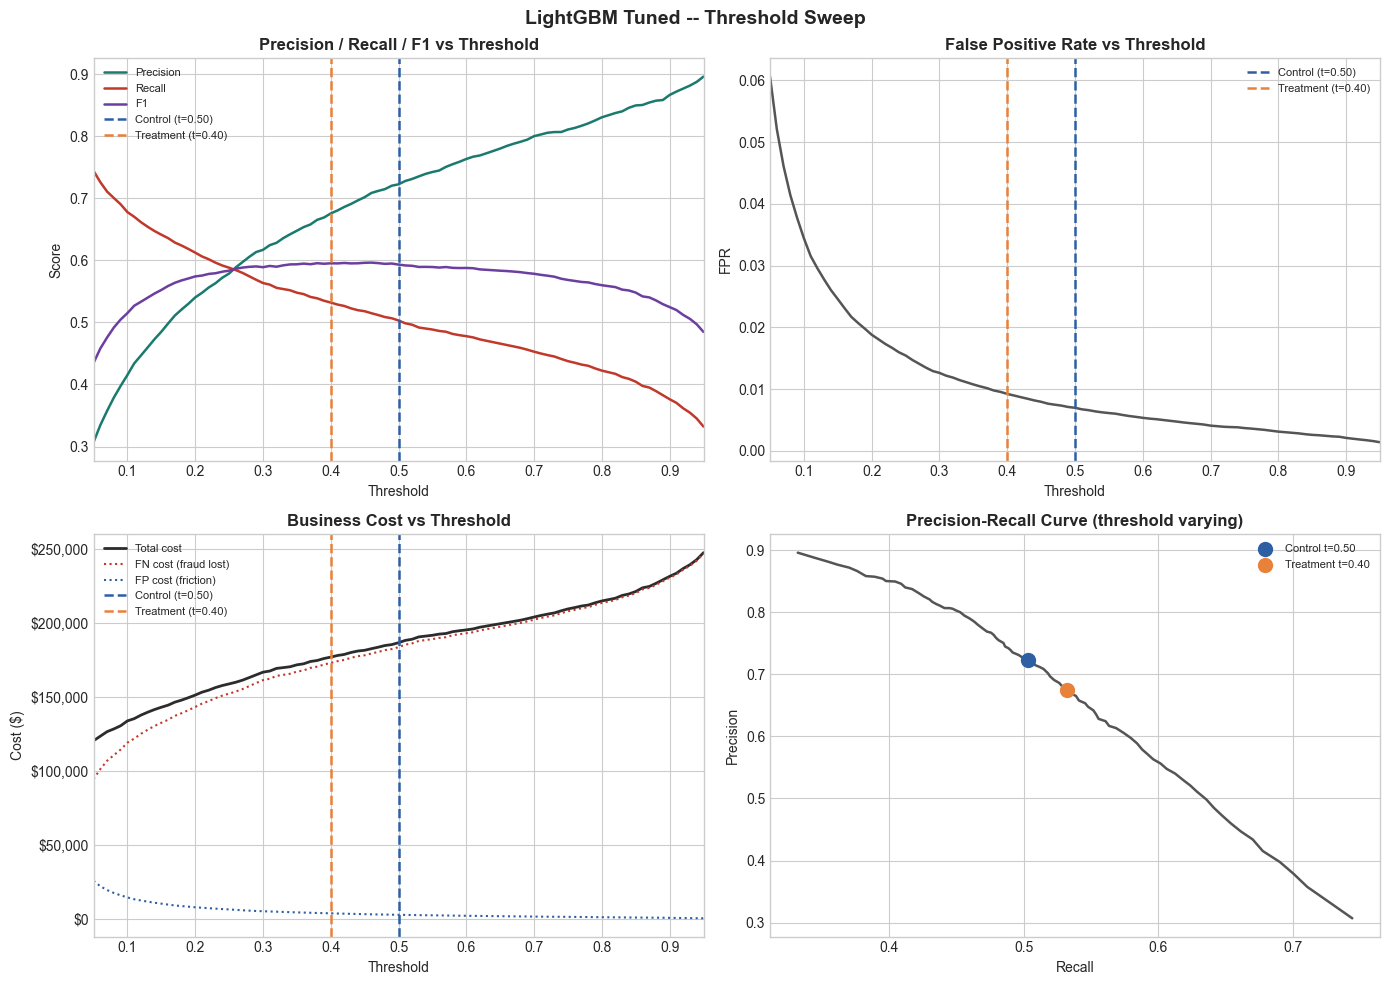

In [34]:
thresholds = np.arange(0.05, 0.96, 0.01)
rows = []

for t in thresholds:
    y_pred = (prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    fpr  = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    cost = fn * avg_fraud_amt + fp * false_positive_cost
    rows.append(dict(threshold=t, precision=prec, recall=rec,
                     f1=f1, fpr=fpr, total_cost=cost,
                     fn_cost=fn*avg_fraud_amt, fp_cost=fp*false_positive_cost))

sweep = pd.DataFrame(rows)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('LightGBM Tuned -- Threshold Sweep', fontsize=14, fontweight='bold')

ctrl_c  = '#2E5FA3'
trt_c   = '#E8813A'
sweep_c = '#555555'

def vlines(ax):
    ax.axvline(thresh_control,   color=ctrl_c, lw=1.8, linestyle='--',
               label=f'Control (t={thresh_control:.2f})')
    ax.axvline(thresh_treatment, color=trt_c,  lw=1.8, linestyle='--',
               label=f'Treatment (t={thresh_treatment:.2f})')

# Plot 1: Precision / Recall / F1
ax = axes[0, 0]
ax.plot(sweep['threshold'], sweep['precision'], label='Precision', color='#1A7A6E', lw=1.8)
ax.plot(sweep['threshold'], sweep['recall'],    label='Recall',    color='#C0392B', lw=1.8)
ax.plot(sweep['threshold'], sweep['f1'],        label='F1',        color='#6B3FA0', lw=1.8)
vlines(ax)
ax.set_title('Precision / Recall / F1 vs Threshold', fontweight='bold')
ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
ax.legend(fontsize=8); ax.set_xlim(0.05, 0.95)

# Plot 2: FPR
ax = axes[0, 1]
ax.plot(sweep['threshold'], sweep['fpr'], color=sweep_c, lw=1.8)
vlines(ax)
ax.set_title('False Positive Rate vs Threshold', fontweight='bold')
ax.set_xlabel('Threshold'); ax.set_ylabel('FPR')
ax.legend(fontsize=8); ax.set_xlim(0.05, 0.95)

# Plot 3: Business cost
ax = axes[1, 0]
ax.plot(sweep['threshold'], sweep['total_cost'],  label='Total cost',    color='#2C2C2C', lw=2)
ax.plot(sweep['threshold'], sweep['fn_cost'],     label='FN cost (fraud lost)',   color='#C0392B', lw=1.5, linestyle=':')
ax.plot(sweep['threshold'], sweep['fp_cost'],     label='FP cost (friction)',     color='#2E5FA3', lw=1.5, linestyle=':')
vlines(ax)
ax.set_title('Business Cost vs Threshold', fontweight='bold')
ax.set_xlabel('Threshold'); ax.set_ylabel('Cost ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax.legend(fontsize=8); ax.set_xlim(0.05, 0.95)

# Plot 4: Precision-Recall tradeoff
ax = axes[1, 1]
ax.plot(sweep['recall'], sweep['precision'], color=sweep_c, lw=1.8)
# Marking the two thresholds
ctrl_row = sweep.iloc[(sweep['threshold'] - thresh_control).abs().argmin()]
trt_row  = sweep.iloc[(sweep['threshold'] - thresh_treatment).abs().argmin()]
ax.scatter(ctrl_row['recall'], ctrl_row['precision'], color=ctrl_c, s=100, zorder=5,
           label=f'Control t={thresh_control:.2f}')
ax.scatter(trt_row['recall'],  trt_row['precision'],  color=trt_c,  s=100, zorder=5,
           label=f'Treatment t={thresh_treatment:.2f}')
ax.set_title('Precision-Recall Curve (threshold varying)', fontweight='bold')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.legend(fontsize=8)

plt.tight_layout()
#plt.savefig('outputs/plots/04_threshold_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

### Statistical Significance

We conduct two tests on the same comparison: control threshold (0.5) vs treatment threshold (optimal). The model and test set are identical for both -- we are testing whether the threshold change produces a reliably different outcome.

| Test | What it checks |
|------|----------------|
| Two-proportion z-test | Difference in recall (fraud detection rate) |
| Two-proportion z-test | Difference in FPR (false alarm rate) |

In [35]:
alpha = 0.05
n_fraud    = int(y_test.sum())
n_legit    = int((y_test == 0).sum())

#  Z-test on recall (TP rate on fraud cases)
tp_ctrl = int(m_ctrl['tp'])
tp_trt  = int(m_trt['tp'])

z_rec, p_rec = proportions_ztest(
    np.array([tp_ctrl, tp_trt]),
    np.array([n_fraud, n_fraud]),
    alternative='two-sided'
)

print('Two-Proportion Z-Test -- Recall (Fraud Detection Rate)')
print(f'H0: recall(control) == recall(treatment)')
print(f'Control recall: {tp_ctrl}/{n_fraud} = {m_ctrl["recall"]:.4f}')
print(f'Treatment recall: {tp_trt}/{n_fraud}  = {m_trt["recall"]:.4f}')
print(f'Delta recall: {m_trt["recall"] - m_ctrl["recall"]:+.4f}')
print(f'Z-statistic: {z_rec:.4f}')
print(f'p-value: {p_rec:.6f}')
print(f'Significant (a={alpha}): {p_rec < alpha}')
print()

# Z-test on FPR (false alarm rate on legitimate transactions)
fp_ctrl = int(m_ctrl['fp'])
fp_trt  = int(m_trt['fp'])

z_fpr, p_fpr = proportions_ztest(
    np.array([fp_ctrl, fp_trt]),
    np.array([n_legit, n_legit]),
    alternative='two-sided'
)

print('Two-Proportion Z-Test -- FPR (False Alarm Rate)')
print(f'H0: FPR(control) == FPR(treatment)')
print(f'Control   FPR: {fp_ctrl}/{n_legit} = {m_ctrl["fpr"]:.4f}')
print(f'Treatment FPR: {fp_trt}/{n_legit}  = {m_trt["fpr"]:.4f}')
print(f'Delta FPR : {m_trt["fpr"] - m_ctrl["fpr"]:+.4f}')
print(f'Z-statistic : {z_fpr:.4f}')
print(f'p-value : {p_fpr:.6f}')
print(f'Significant (a={alpha}): {p_fpr < alpha}')

Two-Proportion Z-Test -- Recall (Fraud Detection Rate)
H0: recall(control) == recall(treatment)
Control recall: 1551/3083 = 0.5031
Treatment recall: 1640/3083  = 0.5319
Delta recall: +0.0289
Z-statistic: -2.2682
p-value: 0.023316
Significant (a=0.05): True

Two-Proportion Z-Test -- FPR (False Alarm Rate)
H0: FPR(control) == FPR(treatment)
Control   FPR: 596/85498 = 0.0070
Treatment FPR: 788/85498  = 0.0092
Delta FPR : +0.0022
Z-statistic : -5.1820
p-value : 0.000000
Significant (a=0.05): True


### Practical Significance

Statistical significance tells us whether the threshold difference is real.
Practical significance tells us whether it is large enough to justify shipping the model to production.

| Metric | What it answers |
|--------|----------------|
| Cohen's h | Is the recall improvement meaningful in effect-size terms? |
| MDE | What is the smallest recall change this test can reliably detect? |
| Business Cost Delta | What is the difference in the money spent on missed fraud and false alarms ? |

In [36]:
# Cohen's h on recall
h = proportion_effectsize(m_trt['recall'], m_ctrl['recall'])

abs_h = abs(h)
if abs_h < 0.20:   es_label = 'Negligible'
elif abs_h < 0.50: es_label = 'Small'
elif abs_h < 0.80: es_label = 'Medium'
else:              es_label = 'Large'

print("Cohen's h -- Recall Effect Size")
print(f'Control recall: {m_ctrl["recall"]:.4f}')
print(f'Treatment recall: {m_trt["recall"]:.4f}')
print(f"Cohen's h : {h:.4f}  ({es_label})")
print()
print('Conventional thresholds:')
print(f'|h| < 0.20 -> Negligible {"<< here" if abs_h < 0.20 else ""}')
print(f'|h| < 0.50 -> Small {"<< here" if 0.20 <= abs_h < 0.50 else ""}')
print(f'|h| < 0.80 -> Medium {"<< here" if 0.50 <= abs_h < 0.80 else ""}')
print(f'|h| >= 0.80 -> Large {"<< here" if abs_h >= 0.80 else ""}')

# Business cost delta
print()
print('Business Cost Delta')
print(f'Avg_Fraud_Amt : ${avg_fraud_amt:.2f} per missed fraud (FN)')
print(f'false_positive_cost : ${false_positive_cost:.2f} per wrong block (FP)')
print()
w = 42
print(f'{"":{w}} {"Control":>12} {"Treatment":>12} {"Delta":>10}')
fn_d = (m_trt['fn'] - m_ctrl['fn']) * avg_fraud_amt
fp_d = (m_trt['fp'] - m_ctrl['fp']) * false_positive_cost
print(f' {"Missed-fraud cost (FN x $120)":{w}} {m_ctrl["fn_cost"]:>12,.0f} {m_trt["fn_cost"]:>12,.0f} {fn_d:>+10,.0f}')
print(f' {"False-block cost  (FP x $5)":{w}} {m_ctrl["fp_cost"]:>12,.0f} {m_trt["fp_cost"]:>12,.0f} {fp_d:>+10,.0f}')
print()

Cohen's h -- Recall Effect Size
Control recall: 0.5031
Treatment recall: 0.5319
Cohen's h : 0.0578  (Negligible)

Conventional thresholds:
|h| < 0.20 -> Negligible << here
|h| < 0.50 -> Small 
|h| < 0.80 -> Medium 
|h| >= 0.80 -> Large 

Business Cost Delta
Avg_Fraud_Amt : $120.00 per missed fraud (FN)
false_positive_cost : $5.00 per wrong block (FP)

                                                Control    Treatment      Delta
 Missed-fraud cost (FN x $120)                   183,840      173,160    -10,680
 False-block cost  (FP x $5)                       2,980        3,940       +960



In [37]:
# Power analysis and MDE
power_analysis = NormalIndPower()

observed_h = abs(proportion_effectsize(m_trt['recall'], m_ctrl['recall']))
achieved_power = power_analysis.solve_power(
    effect_size=observed_h if observed_h > 1e-6 else 1e-6,
    nobs1=n_fraud, alpha=alpha, alternative='two-sided'
)

mde_h = power_analysis.solve_power(
    nobs1=n_fraud, alpha=alpha, power=0.80, alternative='two-sided'
)

# Convert MDE Cohen's h back to recall units
phi_ctrl   = 2 * np.arcsin(np.sqrt(m_ctrl['recall']))
mde_recall = np.sin((phi_ctrl + mde_h) / 2) ** 2 - m_ctrl['recall']

print('Statistical Power and MDE')
print(f'Fraud cases in test set (n): {n_fraud:,}')
print(f'Significance level (a): {alpha}')
print(f'Target power: 0.80')
print(f"Observed Cohen's h: {observed_h:.4f}")
print(f'Achieved power: {achieved_power:.4f} '
      f'{"(adequate >= 0.80)" if achieved_power >= 0.80 else "(underpowered < 0.80)"}')
print(f"MDE (Cohen's h): {mde_h:.4f}")
print(f'MDE in recall units: +{mde_recall:.4f}')
print(f'(smallest recall change reliably detectable with this sample size)')

Statistical Power and MDE
Fraud cases in test set (n): 3,083
Significance level (a): 0.05
Target power: 0.80
Observed Cohen's h: 0.0578
Achieved power: 0.6212 (underpowered < 0.80)
MDE (Cohen's h): 0.0714
MDE in recall units: +0.0356
(smallest recall change reliably detectable with this sample size)


### Visual Summary -- Control vs Treatment Comparison

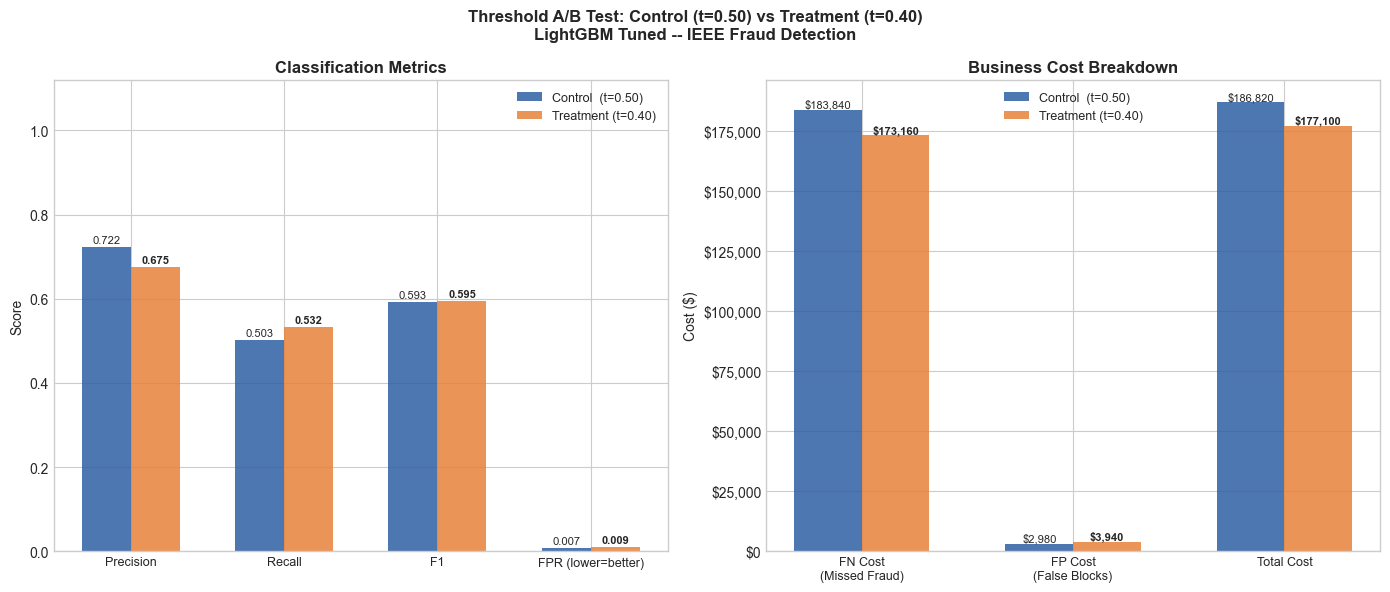

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    f'Threshold A/B Test: Control (t=0.50) vs Treatment (t={thresh_treatment:.2f})'
    f'\nLightGBM Tuned -- IEEE Fraud Detection',
    fontsize=12, fontweight='bold'
)

ctrl_c = '#2E5FA3'
trt_c  = '#E8813A'

# Panel 1: Classification metrics
ax = axes[0]
metrics_to_show = ['precision', 'recall', 'f1', 'fpr']
labels_show     = ['Precision', 'Recall', 'F1', 'FPR (lower=better)']
x   = np.arange(len(metrics_to_show))
w   = 0.32

ctrl_vals = [m_ctrl[k] for k in metrics_to_show]
trt_vals  = [m_trt[k]  for k in metrics_to_show]

bars_c = ax.bar(x - w/2, ctrl_vals, w, label=f'Control  (t=0.50)', color=ctrl_c, alpha=0.85)
bars_t = ax.bar(x + w/2, trt_vals,  w, label=f'Treatment (t={thresh_treatment:.2f})', color=trt_c, alpha=0.85)

for bar, v in zip(bars_c, ctrl_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{v:.3f}', ha='center', va='bottom', fontsize=8)
for bar, v in zip(bars_t, trt_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{v:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(labels_show, fontsize=9)
ax.set_ylim(0, 1.12); ax.set_ylabel('Score')
ax.set_title('Classification Metrics', fontweight='bold')
ax.legend(fontsize=9)

# Panel 2: Business cost breakdown
ax2 = axes[1]
cost_cats  = ['FN Cost\n(Missed Fraud)', 'FP Cost\n(False Blocks)', 'Total Cost']
ctrl_costs = [m_ctrl['fn_cost'], m_ctrl['fp_cost'], m_ctrl['total_cost']]
trt_costs  = [m_trt['fn_cost'],  m_trt['fp_cost'],  m_trt['total_cost']]

x2     = np.arange(len(cost_cats))
bars_c = ax2.bar(x2 - w/2, ctrl_costs, w, label=f'Control  (t=0.50)', color=ctrl_c, alpha=0.85)
bars_t = ax2.bar(x2 + w/2, trt_costs,  w, label=f'Treatment (t={thresh_treatment:.2f})', color=trt_c, alpha=0.85)

for bar, v in zip(bars_c, ctrl_costs):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f'${v:,.0f}', ha='center', va='bottom', fontsize=8)
for bar, v in zip(bars_t, trt_costs):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f'${v:,.0f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax2.set_xticks(x2); ax2.set_xticklabels(cost_cats, fontsize=9)
ax2.set_ylabel('Cost ($)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax2.set_title('Business Cost Breakdown', fontweight='bold')
ax2.legend(fontsize=9)

plt.tight_layout()
#plt.savefig('outputs/plots/04_ab_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Business Cost Delta

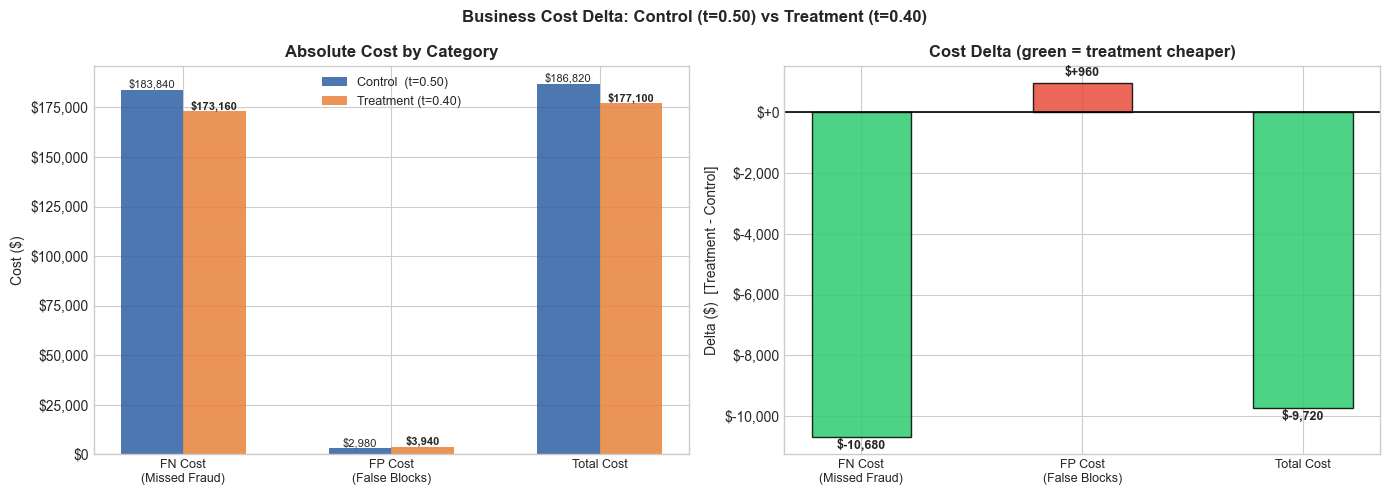

Cost summary:
  Control total cost   : $186,820
  Treatment total cost : $177,100
  Delta (Treatment - Control): $-9,720
  Treatment is cheaper: True


In [39]:
# Business Cost Delta -- bar chart
ctrl_c = '#2E5FA3'
trt_c  = '#E8813A'

cost_cats  = ['FN Cost\n(Missed Fraud)', 'FP Cost\n(False Blocks)', 'Total Cost']
ctrl_costs = [m_ctrl['fn_cost'], m_ctrl['fp_cost'], m_ctrl['total_cost']]
trt_costs  = [m_trt['fn_cost'],  m_trt['fp_cost'],  m_trt['total_cost']]
deltas     = [t - c for t, c in zip(trt_costs, ctrl_costs)]

x  = np.arange(len(cost_cats))
w  = 0.30

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    f'Business Cost Delta: Control (t=0.50) vs Treatment (t={thresh_treatment:.2f})',
    fontsize=12, fontweight='bold'
)

# Panel 1: Side-by-side cost bars
ax = axes[0]
bars_c = ax.bar(x - w/2, ctrl_costs, w, label='Control  (t=0.50)',
                color=ctrl_c, alpha=0.85)
bars_t = ax.bar(x + w/2, trt_costs,  w, label=f'Treatment (t={thresh_treatment:.2f})',
                color=trt_c,  alpha=0.85)

for bar, v in zip(bars_c, ctrl_costs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'${v:,.0f}', ha='center', va='bottom', fontsize=8)
for bar, v in zip(bars_t, trt_costs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'${v:,.0f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(cost_cats, fontsize=9)
ax.set_ylabel('Cost ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax.set_title('Absolute Cost by Category', fontweight='bold')
ax.legend(fontsize=9)

# Panel 2: Delta bars (Treatment - Control)
ax2 = axes[1]
colors = ['#2ecc71' if d <= 0 else '#e74c3c' for d in deltas]
bars_d = ax2.bar(x, deltas, width=0.45, color=colors, alpha=0.85, edgecolor='black')

for bar, v in zip(bars_d, deltas):
    ypos = bar.get_height() + 150 if v >= 0 else bar.get_height() - 500
    ax2.text(bar.get_x() + bar.get_width()/2, ypos,
             f'${v:+,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax2.axhline(0, color='black', lw=1.2)
ax2.set_xticks(x); ax2.set_xticklabels(cost_cats, fontsize=9)
ax2.set_ylabel('Delta ($)  [Treatment - Control]')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:+,.0f}'))
ax2.set_title('Cost Delta (green = treatment cheaper)', fontweight='bold')

plt.tight_layout()
plt.show()

# Summary print
total_delta = m_trt['total_cost'] - m_ctrl['total_cost']
cost_better = total_delta < 0
print(f'Cost summary:')
print(f'  Control total cost   : ${m_ctrl["total_cost"]:,.0f}')
print(f'  Treatment total cost : ${m_trt["total_cost"]:,.0f}')
print(f'  Delta (Treatment - Control): ${total_delta:+,.0f}')
print(f'  Treatment is cheaper: {cost_better}')

### Decision Report

In [42]:
# Pre-format all values to avoid f-string conflicts
rec_ctrl = f'{m_ctrl["recall"]:.4f}'
rec_trt = f'{m_trt["recall"]:.4f}'
d_rec = f'{m_trt["recall"] - m_ctrl["recall"]:+.4f}'
fpr_ctrl = f'{m_ctrl["fpr"]:.4f}'
fpr_trt = f'{m_trt["fpr"]:.4f}'
d_fpr = f'{m_trt["fpr"] - m_ctrl["fpr"]:+.4f}'
p_rec_s = f'{p_rec:.6f}'
p_fpr_s = f'{p_fpr:.6f}'
h_s = f'{h:.4f}'
pwr_s = f'{achieved_power:.4f}'
mde_s = f'+{mde_recall:.4f}'

stat_sig_rec = p_rec < alpha
stat_sig_fpr = p_fpr < alpha
prac_sig_h = abs(h) >= 0.05
powered = achieved_power >= 0.80
fpr_sig = p_fpr < 0.05
cost_better = (m_trt['total_cost'] - m_ctrl['total_cost']) < 0

n_criteria = sum([stat_sig_rec, stat_sig_fpr, prac_sig_h, fpr_sig, cost_better])

if n_criteria >= 3:
    verdict = 'Deploy'
elif n_criteria >= 2:
    verdict = 'Inconclusive -- gather more data or run live traffic experiment'
else:
    verdict = 'Retain Control -- treatment threshold shows no meaningful improvement'

print('A/B Test Decision Report')
print(f'Model    : XGBoost (Tuned)')
print(f'Control  : threshold = {thresh_control:.2f} (default)')
print(f'Treatment: threshold = {thresh_treatment:.2f} (business-cost optimal, notebook 03)')
print(f'Test set : {len(y_test):,} transactions | {n_fraud:,} fraud cases')
print()
print('Primary Metrics')
print(f'Recall  -- Control: {rec_ctrl}  Treatment: {rec_trt}  Delta: {d_rec}')
print(f'FPR     -- Control: {fpr_ctrl}  Treatment: {fpr_trt}  Delta: {d_fpr}')
print()
print('Statistical Significance')
print(f'Z-test recall  p={p_rec_s}  : {"Significant" if stat_sig_rec else "Not Significant"}')
print(f'Z-test FPR     p={p_fpr_s}  : {"Significant" if stat_sig_fpr else "Not Significant"}')
print(f'Achieved power: {pwr_s}  MDE: {mde_s} recall units')
print()
print('Practical Significance')
cost_delta_str = f'${m_trt["total_cost"] - m_ctrl["total_cost"]:+,.0f}'
print(f"Cohen's h = {h_s} ({es_label}): {'Non-Negligible' if prac_sig_h else 'Negligible'}")
print(f'Business cost delta : {cost_delta_str}  Treatment cheaper: {cost_better}')
print()
print(f'Criteria Met: {n_criteria}/5')
print()
print(f'Verdict: {verdict}')
print()

A/B Test Decision Report
Model    : XGBoost (Tuned)
Control  : threshold = 0.50 (default)
Treatment: threshold = 0.40 (business-cost optimal, notebook 03)
Test set : 88,581 transactions | 3,083 fraud cases

Primary Metrics
Recall  -- Control: 0.5031  Treatment: 0.5319  Delta: +0.0289
FPR     -- Control: 0.0070  Treatment: 0.0092  Delta: +0.0022

Statistical Significance
Z-test recall  p=0.023316  : Significant
Z-test FPR     p=0.000000  : Significant
Achieved power: 0.6212  MDE: +0.0356 recall units

Practical Significance
Cohen's h = 0.0578 (Negligible): Non-Negligible
Business cost delta : $-9,720  Treatment cheaper: True

Criteria Met: 5/5

Verdict: Deploy

